In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import kagglehub
import os

# Descargar el dataset de Spotify
path = kagglehub.dataset_download("serkantysz/550k-spotify-songs-audio-lyrics-and-genres")
files = [f for f in os.listdir(path) if f.endswith('.csv')]
df_raw = pd.read_csv(os.path.join(path, files[0]))

# Seleccionamos una muestra representativa y las columnas clave
df = df_raw[['followers', 'popularity']].dropna().sample(n=20000, random_state=42)
X = df.values

print(f"Dataset listo con {X.shape[0]} registros.")

Dataset listo con 20000 registros.


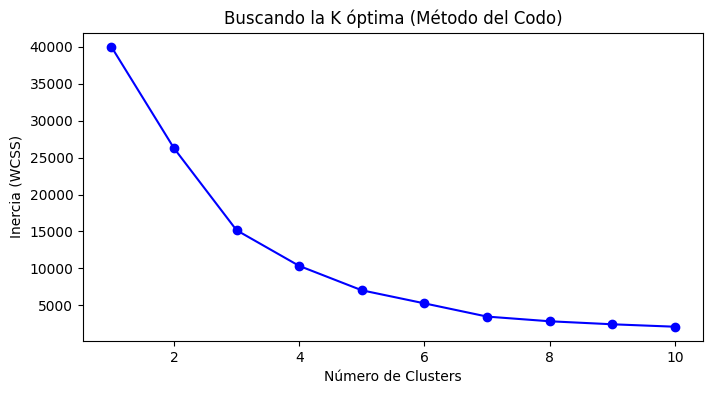

In [8]:
# Escalamos para que el método del codo sea preciso
scaler_elbow = StandardScaler()
X_scaled_elbow = scaler_elbow.fit_transform(X)

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init="auto")
    km.fit(X_scaled_elbow)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='blue')
plt.title('Buscando la K óptima (Método del Codo)')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia (WCSS)')
plt.show()

In [9]:
# 80% para entrenar el modelo, 20% para probar su capacidad de predicción
X_train, X_test = train_test_split(X, test_size=0.20, random_state=42)

print(f"Registros para entrenamiento (80%): {len(X_train)}")
print(f"Registros para prueba (20%): {len(X_test)}")

Registros para entrenamiento (80%): 16000
Registros para prueba (20%): 4000


In [10]:
# Pipeline: Escalado + Clustering
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, random_state=42, n_init="auto"))
])

# ENTRENAMIENTO (Fit) con el 80%
pipe.fit(X_train)

# PREDICCIÓN (Predict) con el 20%
test_clusters = pipe.predict(X_test)

df_test = pd.DataFrame(X_test, columns=["followers", "popularity"])
df_test["cluster"] = test_clusters

print("Resultado de la predicción en el 20% de Test:")
print(df_test.head())

Resultado de la predicción en el 20% de Test:
   followers  popularity  cluster
0       6137          51        3
1      31754          46        3
2      12210          32        0
3        218           5        1
4      16703          26        0



Predicción para nuevos artistas:
Seguidores: 500, Popularidad: 10 => Cluster 1
Seguidores: 100,000, Popularidad: 50 => Cluster 3
Seguidores: 5,000,000, Popularidad: 95 => Cluster 3


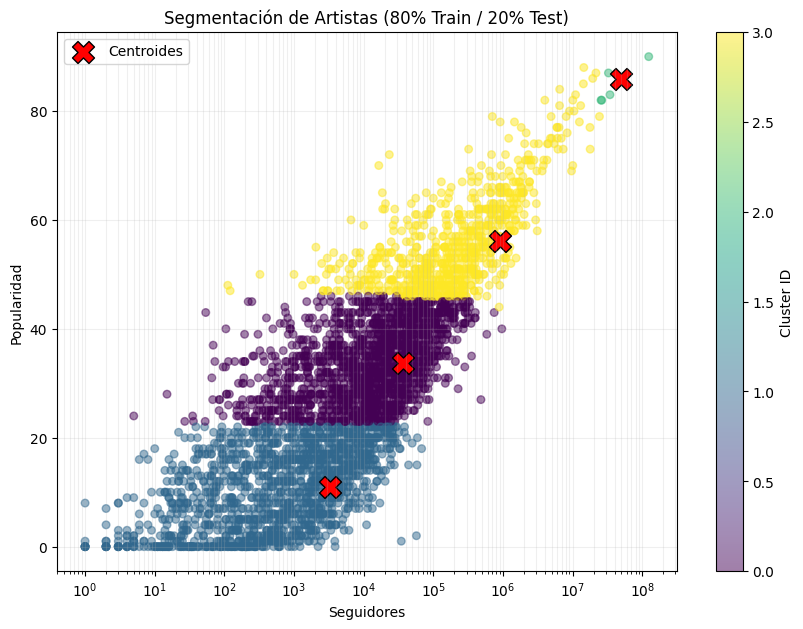


--- Promedios por Cluster en el set de Test ---
            followers  popularity
cluster                          
0        3.504131e+04   33.526528
1        3.249049e+03   10.844895
2        4.852526e+07   84.800000
3        8.646693e+05   55.800819


In [12]:
# 4) Ejemplo de predicción para "Artistas Nuevos"
# Formato: [Seguidores, Popularidad]
nuevos_artistas = np.array([
    [500, 10],       # Artista muy pequeño/nuevo
    [100000, 50],    # Artista de nicho con seguidores fieles
    [5000000, 95]    # Superestrella mundial
])

clusters_nuevos = pipe.predict(nuevos_artistas)

print("\nPredicción para nuevos artistas:")
for data, cluster in zip(nuevos_artistas, clusters_nuevos):
    print(f"Seguidores: {data[0]:,}, Popularidad: {data[1]} => Cluster {cluster}")

# 5) Visualización de resultados (IMAGEN)
# Recuperamos los centroides y deshacemos el escalado para graficarlos en la escala real
centroids_scaled = pipe.named_steps["kmeans"].cluster_centers_
centroids = pipe.named_steps["scaler"].inverse_transform(centroids_scaled)

plt.figure(figsize=(10, 7))

# Graficamos el 20% de Test
scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=test_clusters, s=30, alpha=0.5, cmap='viridis')
# Graficamos los centroides
plt.scatter(centroids[:, 0], centroids[:, 1], s=250, marker="X", edgecolors="k", color='red', label='Centroides')

plt.title("Segmentación de Artistas (80% Train / 20% Test)")
plt.xlabel("Seguidores")
plt.ylabel("Popularidad")

# Usamos escala logarítmica en el eje X porque hay artistas de 0 y otros de 100M
plt.xscale('log') 

plt.colorbar(scatter, label='Cluster ID')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# Extra: Ver los promedios reales de cada cluster
df_analisis = pd.DataFrame(X_test, columns=["followers", "popularity"])
df_analisis["cluster"] = test_clusters
print("\n--- Promedios por Cluster en el set de Test ---")
print(df_analisis.groupby("cluster").mean())